In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr, zscore
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tf.keras.backend.clear_session()

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

### Experimenting with one held out tissue type in tcga sample

In [2]:
import glob, os
os.chdir("/data/kumarr17/tcga_exp/")
tcga_data_df=[] 
for i in glob.glob("*"+'.tsv'):
    tcga_data_df.append(i)
os.chdir("/data/kumarr17/tcga_exp/") 

In [3]:
tcga_data_df_list=[]
for i in range(33):
    tcga_data_df_frame=pd.read_csv("/data/kumarr17/tcga_exp/"+tcga_data_df[i],sep='\t',index_col='Hybridization REF').T
    tcga_data_df_frame['tissue_type']=tcga_data_df[i].split('.')[0]
    tcga_data_df_list.append(tcga_data_df_frame)

In [4]:
df_tcga_concat=pd.concat(tcga_data_df_list)

In [5]:
df_tcga_concat

Hybridization REF,A1BG,A1CF,A2BP1,A2LD1,A2ML1,A2M,A4GALT,A4GNT,AAA1,AAAS,...,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,psiTPTE22,tAKR,tissue_type
TCGA-OR-A5J1-01A-11R-A29S-07,16.3305,0.0000,17.2911,182.3919,54.7550,10373.6984,190.6820,0.0000,0.0,2225.2642,...,351.5850,1050.9126,0.4803,648.4150,1841.0183,1157.5408,596.0615,715.6580,0.9606,ACC
TCGA-OR-A5J2-01A-11R-A29S-07,9.5987,0.0000,5.6368,239.1584,0.0000,9844.9128,198.8994,0.0000,0.0,1509.4613,...,279.0229,2979.8675,31.4052,1166.0176,3059.9909,1895.9865,801.6371,581.8009,0.4026,ACC
TCGA-OR-A5J3-01A-11R-A29S-07,20.7377,0.5925,8.8876,138.8831,1.7775,7201.8368,75.2481,2.3700,0.0,1259.6652,...,495.3340,914.8274,0.5925,806.3991,2655.6066,1482.4470,437.2686,126.7960,0.0000,ACC
TCGA-OR-A5J5-01A-11R-A29S-07,1696.6615,1.5492,6.1967,63.9349,49.5740,2939.0395,374.9032,0.7746,0.0,2993.8033,...,206.0418,890.7823,11.6189,553.8342,2367.9318,1140.2014,512.7808,855.1510,0.0000,ACC
TCGA-OR-A5J6-01A-31R-A29S-07,600.1618,0.0000,4.4709,237.3520,1.1177,9586.9630,1556.4159,0.5589,0.0,1186.4528,...,117.9188,894.7296,7.8240,795.8119,708.0714,796.3708,475.5870,288.3701,0.0000,ACC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-YZ-A980-01A-11R-A405-07,169.7164,0.4110,161.1180,124.4184,17.6737,26469.1862,110.1521,0.8220,0.0,1069.8726,...,261.8167,873.8183,0.0000,939.5808,2103.5758,1836.0049,707.3572,11.0974,0.0000,UVM
TCGA-YZ-A982-01A-11R-A405-07,164.0177,0.0000,3.5398,69.5044,0.8850,21411.5575,30.9735,0.0000,0.0,1774.3363,...,106.1947,887.6106,0.8850,266.3717,3633.6283,2537.1681,250.4425,1216.8142,0.0000,UVM
TCGA-YZ-A983-01A-11R-A405-07,602.6847,0.0000,0.0000,185.2648,1.8473,47147.4138,35.0985,2.4631,0.0,866.3793,...,174.8768,915.0246,3.0788,731.5271,2626.2315,1494.4581,816.5025,49.2611,0.0000,UVM
TCGA-YZ-A984-01A-11R-A405-07,56.5994,0.0000,41.7537,34.0988,0.9279,28654.6602,121.5495,0.0000,0.0,3109.2554,...,83.5073,492.6931,0.0000,266.2955,3988.8657,2299.2345,347.0193,900.0232,0.0000,UVM


In [6]:
tcga_features = pd.read_csv("/data/kumarr17/common_features_ver3.txt", header=None)
cyt_features = pd.read_csv("/data/kumarr17/common_cyt_nichenet_gulden_tcga.txt", header=None)
tcga_features_list=list(tcga_features[0])
cyt_features_list=list(cyt_features[0])
filtered_model_feature_list=tcga_features_list
cyt_of_interest=cyt_features_list

In [7]:
df_tcga_features=df_tcga_concat[filtered_model_feature_list]
df_tcga_cyt_col=df_tcga_concat[cyt_of_interest]

In [8]:
df_tcga_features['tissue_type']=list(df_tcga_concat['tissue_type'])

/tmp/ipykernel_215774/4229581879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tcga_features['tissue_type']=list(df_tcga_concat['tissue_type'])


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()

cyt_tmp = cyt_of_interest
corr_new_tmp = []

# Last column contains tissue labels
tissue_col = df_tcga_features.columns[-1]
groups = df_tcga_features[tissue_col].astype(str).to_numpy()

# Remove tissue label column from model input
X_raw = (
    df_tcga_features
    .iloc[:, :-1]
    .apply(pd.to_numeric, errors="coerce")
    .fillna(0)
    .to_numpy(dtype="float32")
)

# Optional row-wise z-score
X_raw = (X_raw - X_raw.mean(axis=1, keepdims=True)) / (
    X_raw.std(axis=1, keepdims=True) + 1e-8
)

logo = LeaveOneGroupOut()


def build_fcnn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model


def safe_pearson(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    valid = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[valid]
    y_pred = y_pred[valid]

    if len(y_true) < 2:
        return np.nan

    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        return np.nan

    return pearsonr(y_true, y_pred)[0]


all_fold_results = []

for cytokine_to_check in cyt_tmp:

    print("\n" + "=" * 50)
    print(f"Cytokine: {cytokine_to_check}")
    print("=" * 50)

    y = (
        df_tcga_cyt_col[cytokine_to_check]
        .to_numpy(dtype="float32")
        .reshape(-1, 1)
    )

    corr_lt = []

    for fold, (train_index, val_index) in enumerate(
        logo.split(X_raw, y, groups),
        start=1
    ):

        held_out_tissue = np.unique(groups[val_index])[0]

        X_train_raw = X_raw[train_index]
        X_val_raw = X_raw[val_index]

        y_train = y[train_index]
        y_val = y[val_index]

        # Scale using training tissues only
        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train_raw).astype("float32")
        X_val = scaler.transform(X_val_raw).astype("float32")

        tf.keras.backend.clear_session()
        model = build_fcnn(X_train.shape[1])

        early_stop = keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=128,
            verbose=0,
            callbacks=[early_stop]
        )

        y_pred = model.predict(X_val, verbose=0).ravel()
        y_true = y_val.ravel()

        corr = safe_pearson(y_true, y_pred)
        corr_lt.append(corr)

        all_fold_results.append({
            "cytokine": cytokine_to_check,
            "held_out_tissue": held_out_tissue,
            "n_test_samples": len(val_index),
            "pearson_correlation": corr
        })

        print(
            f"Fold {fold}: held out {held_out_tissue}, "
            f"n={len(val_index)}, Pearson={corr}"
        )

    mean_corr = np.nanmean(corr_lt)
    corr_new_tmp.append(mean_corr)

    print("Mean leave-one-tissue-out Pearson:", mean_corr)


# Mean CV performance for each cytokine
CV_df = pd.DataFrame(
    {"Leave_one_tissue_out_CV": corr_new_tmp},
    index=cyt_tmp
)

# Tissue-specific fold results
fold_results_df = pd.DataFrame(all_fold_results)


Cytokine: INHA


2026-09-14 20:13:58.027850: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-09-14 20:13:58.027872: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-09-14 20:13:58.027886: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (cn0013): /proc/driver/nvidia/version does not exist
2026-09-14 20:13:58.030571: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Fold 1: held out ACC, n=78, Pearson=0.5743621763724722
Fold 2: held out BLCA, n=404, Pearson=0.23880616716705266
Fold 3: held out BRCA, n=1082, Pearson=0.2875786603675139
Fold 4: held out CESC, n=301, Pearson=0.7350167520199762
Fold 5: held out CHOL, n=36, Pearson=-0.06564895359678222
Fold 6: held out COAD, n=279, Pearson=0.027745499616742983
Fold 7: held out DLBC, n=48, Pearson=-0.07401729350666052
Fold 8: held out ESCA, n=182, Pearson=0.36915854817134636
Fold 9: held out GBM, n=163, Pearson=0.06799621159001634
Fold 10: held out HNSC, n=515, Pearson=0.2282145792210829
Fold 11: held out KICH, n=65, Pearson=0.05797179568885401
Fold 12: held out KIRC, n=515, Pearson=0.3977245483303889
Fold 13: held out KIRP, n=285, Pearson=0.8588708844342668
Fold 14: held out LAML, n=173, Pearson=-0.050210723984539976
Fold 15: held out LGG, n=514, Pearson=0.08865420128140931
Fold 16: held out LIHC, n=368, Pearson=0.04852713864961614
Fold 17: held out LUAD, n=511, Pearson=0.35153882136432535
Fold 18: held

/usr/local/Anaconda/envs/py3.9/lib/python3.9/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


Fold 11: held out KICH, n=65, Pearson=nan
Fold 12: held out KIRC, n=515, Pearson=0.1877199028953836
Fold 13: held out KIRP, n=285, Pearson=0.03496900120412096
Fold 14: held out LAML, n=173, Pearson=0.05744189033635495
Fold 15: held out LGG, n=514, Pearson=-0.09501604877608731
Fold 16: held out LIHC, n=368, Pearson=0.21464768373068716
Fold 17: held out LUAD, n=511, Pearson=0.2203517303723671
Fold 18: held out LUSC, n=485, Pearson=0.4529489914517693
Fold 19: held out MESO, n=87, Pearson=0.23616721504929192
Fold 20: held out OV, n=300, Pearson=-0.009725638725754524
Fold 21: held out PAAD, n=156, Pearson=0.053892881095450054
Fold 22: held out PCPG, n=178, Pearson=-0.04155273774639368
Fold 23: held out PRAD, n=493, Pearson=0.06801381222126704
Fold 24: held out READ, n=91, Pearson=0.18618207336332354
Fold 25: held out SARC, n=254, Pearson=0.00043484829864206317
Fold 26: held out SKCM, n=434, Pearson=0.06224994520923395
Fold 27: held out STAD, n=405, Pearson=0.02993530058453393
Fold 28: held 

#### Training and validation in held out TCGA tissue cohort plots

In [2]:
fold_results_df=pd.read_csv("/data/kumarr17/fold_results_df.csv")

In [13]:
fold_results_df

,cytokine,held_out_tissue,n_test_samples,pearson_correlation
0,INHA,ACC,78,0.591924
1,INHA,BLCA,404,0.052207
2,INHA,BRCA,1082,0.244343
3,INHA,CESC,301,0.724792
4,INHA,CHOL,36,-0.128674
...,...,...,...,...
160,CCL21,THCA,499,0.797766
161,CCL21,THYM,120,0.076387
162,CCL21,UCEC,184,0.527005
163,CCL21,UCS,57,0.664088


In [14]:
# Rows = cytokine
# Columns = held_out_tissue
# Values = pearson_correlation

corr_matrix = fold_results_df.pivot(
    index='cytokine',
    columns='held_out_tissue',
    values='pearson_correlation'
)

In [18]:
corr_matrix

held_out_tissue,ACC,BLCA,BRCA,CESC,CHOL,COAD,DLBC,ESCA,GBM,HNSC,...,READ,SARC,SKCM,STAD,TGCT,THCA,THYM,UCEC,UCS,UVM
cytokine,,,,,,,,,,,,,,,,,,,,,
BMP6,0.446769,0.365891,0.026838,0.545223,0.214603,0.699070,0.333733,0.316110,0.383475,0.389057,...,0.422554,0.258468,0.266203,0.412620,0.321388,0.113082,0.162823,0.357740,0.363233,0.228123
CCL21,0.800331,0.494531,0.312320,0.189203,0.991677,0.527704,0.168883,0.976525,-0.039646,0.708777,...,0.691769,0.500020,0.864637,0.761953,0.489655,0.797766,0.076387,0.527005,0.664088,0.346535
FGF7,0.430680,0.806397,0.514694,0.574610,0.599334,0.848013,0.223582,0.884199,0.864965,0.614271,...,0.911885,0.627533,0.563853,0.880573,0.803805,0.072730,0.504033,0.392816,0.606476,0.012611
IL25,0.078623,0.080482,0.136421,0.201176,0.161734,0.063753,0.423382,0.234910,0.277291,0.215707,...,0.032941,0.180133,0.131322,0.096091,0.198240,0.279743,0.133547,0.216109,0.145120,0.040704
INHA,0.591924,0.052207,0.244343,0.724792,-0.128674,-0.010602,-0.076865,0.453812,0.013797,-0.013144,...,-0.201606,0.359351,0.244895,0.916737,0.399386,0.022656,0.065138,-0.042721,0.144708,0.226868


In [16]:
corr_matrix
df = corr_matrix.drop(columns=['LAML'])

#### Figure 1C

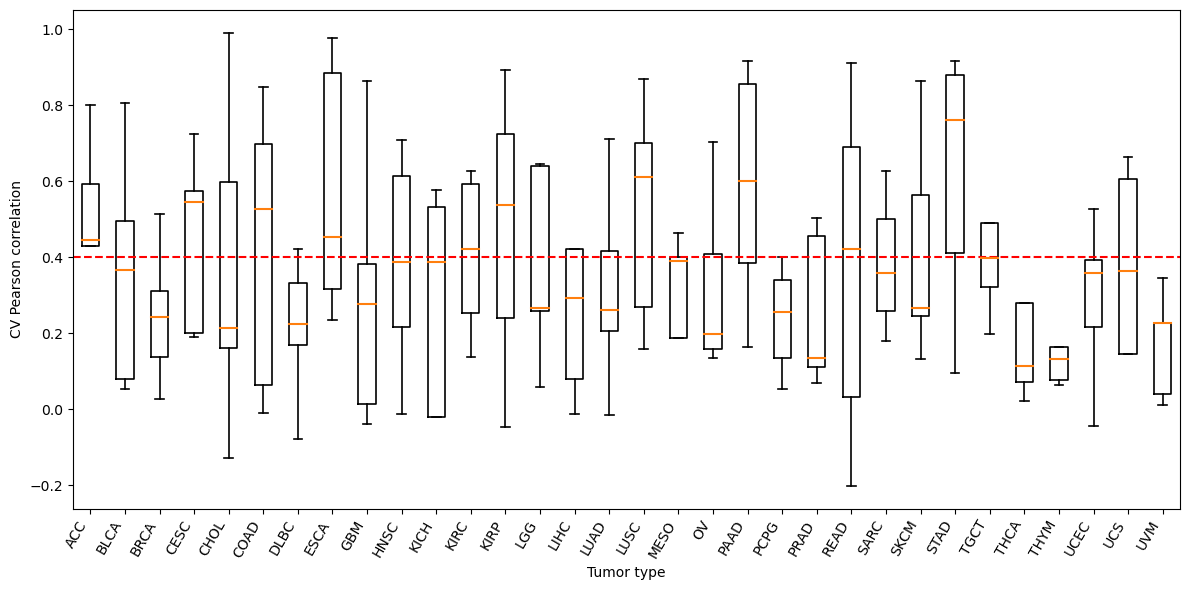

In [17]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

df.boxplot(
    ax=ax,
    showfliers=False,
    boxprops=dict(linewidth=1.2),
    medianprops=dict(linewidth=1.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

# Remove grid
ax.grid(False)

# Reference line at correlation = 0.3
ax.axhline(
    y=0.4,
    color='red',
    linestyle='--',
    linewidth=1.5
)

ax.set_xticklabels(
    df.columns,
    rotation=60,
    ha='right'
)

ax.set_ylabel("CV Pearson correlation")
ax.set_xlabel("Tumor type")

plt.tight_layout()

#plt.savefig(
#    "/data/kumarr17/cytokine_figure_directory/CV_boxplot_by_tissue.svg",
#    format="svg",
#    bbox_inches="tight"
#)

plt.show()